<a href="https://colab.research.google.com/github/nathil/Matematica-Computacional/blob/main/Trabalhos/Atividade_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import math
import random
import pandas as pd
from tabulate import tabulate
from IPython.display import Image, display


#*Funções Utilizadas*

###**Método da Bisseção**

In [49]:
def bissecao(funcao, intervalo, e):
  cont = 0
  #1) Dados Iniciais:

  #a) Intervalo incial [a,b]
  #b) Precisão e

  a,b = intervalo

  #2)

  if (b - a)< e:
    return random.randint(a, b), cont

  #3)
  k=1

  #4)
  M = funcao(a)

  while True:
    cont = cont + 1

    #5)
    x = (a+b)/2

    #6)
    if M * funcao(x) > 0:
      a = x

    #7)
    else:
      b = x

    if (b - a) < e:
      return x, cont

    k = k + 1


###**Método da Posição Falsa**

In [50]:
#Seja f(X) contínua em [a, b] tal que f(a)f(b) < 0

def posicaoFalsa(funcao, intervalo, e):
  cont = 0
  #1) Dados Iniciais

  #a) intervalo incial
  a,b = intervalo

  #b) precisão e1 e e2
  e1 = e
  e2 = e1

  #2)
  if (b-a) < e:
    return (a+b)/2, cont

  if abs(funcao(a))< e2 or abs(funcao(b)) < e2:
    return a, cont

  #3)
  k = 1

  #4)
  M = funcao(a)

  while True:
    cont = cont + 1
    #5)
    x = (a*funcao(b) - b*funcao(a))/ (funcao(b) - funcao(a))

    #6)
    if abs(funcao(x)) < e2:
      return x, cont

    #7)
    if M*funcao(x) > 0:
      a = x

    #8)
    else:
      b = x

    #9)
    if (b - a) < e1:
      return (a+b)/2, cont

    #10)
    k = k + 1

###**Método do Ponto Fixo (MPF)**

In [51]:
def ponto_fixo(funcao, intervalo, e, funcao_eq):
  cont = 0
  #1 Dados Iniciais
  #a)
  x_0, x_1 = intervalo
  #b)
  e1 = e
  e2 = e

  #2)
  if abs(funcao(x_0)) < e1:
    return x_0, cont

  #3)
  k = 1

  while True:
    cont += 1
    #4)
    x_1 = funcao_eq(x_0)

    #5)
    if abs(funcao(x_1)) < e1 or abs(x_1 - x_0) < e2:
      return x_1, cont

    #6)
    x_0 = x_1

    #7)
    k += 1

###**Método de Newton**

In [52]:
def newton_raphson(funcao, intervalo, e, funcao_deriv):
  cont = 0

  #1) Dados inciais
  #a)
  x_0, x_1 = intervalo

  #b)
  e1 = e
  e2 = e

  #2)
  if abs(funcao(x_0)) < e1:
    return x_0, cont

  #3)
  k = 1

  while True:
    cont += 1
    #4)
    x_1 = x_0 - (funcao(x_0)/funcao_deriv(x_0))

    #5)
    if abs(funcao(x_1)) < e1 or abs(x_1 - x_0) < e2:
      return x_1, cont

    #6)
    x_0 = x_1

    #7)
    k += 1

###**Método da Secante**

In [53]:
def secante(funcao, intervalo, e):
  cont = 0
  #1) Dados Iniciais
  #a)
  x_0, x_1 = intervalo

  #b)
  e1 = e
  e2 = e

  #2)
  if abs(funcao(x_0)) < e1:
    return x_0, cont

  #3)
  if abs(funcao(x_1)) < e1 or abs(x_1 - x_0) < e2:
    return x_1, cont

  #4)
  k = 1


  while True:
    cont += 1

    #5)
    x_2 = x_1 - (funcao(x_1)/(funcao(x_1) - funcao(x_0))) * (x_1 - x_0)

    #6)
    if abs(funcao(x_2)) < e1 or abs(x_2 - x_1) < e2:
      return x_2, cont

    #7)
    x_0 = x_1
    x_1 = x_2

    #8)
    k += 1


###**Função Polinômio Exemplo 18**



In [54]:
funcao_ex_18 = lambda x: math.e**(-(x**2)) - math.cos(x) # função normal
funcao_deriv_ex_18 = lambda x: (-2*x)*math.e**(-(x**2)) + math.sin(x) # derivada da função
funcao_eq_ex_18 = lambda x: math.cos(x) - math.e**(-(x**2)) + x # função equivalente


###**Função Polinômio Exemplo 19**

In [55]:
funcao_ex_19 = lambda x: x**3 - x - 1# função normal
funcao_deriv_ex_19 = lambda x: 3*(x**2) - 1 # derivada da função
funcao_eq_ex_19 = lambda x: (x + 1)**(1/3) # função equivalente

###**Função Polinômio Exemplo 20**

In [56]:
funcao_ex_20 = lambda x: 4*math.sin(x) - math.e**x # função normal
funcao_deriv_ex_20 = lambda x: 4*math.cos(x) - math.e**x # derivada da função
funcao_eq_ex_20 = lambda x: x - 2*math.sin(x) + 0.5*math.e**x # função equivalente

###**Função Polinômio Exemplo 21**

In [57]:
funcao_ex_21 = lambda x: x*math.log(x) - 1 # função normal
funcao_deriv_ex_21 = lambda x: math.log(x) + 1 # derivada da função
funcao_eq_ex_21 = lambda x: x - 1.3*(x*(math.log(x) - 1))# função equivalente

###**Mostrando Valores**

In [58]:
def retorna_valores(funcao_escolhida, funcao_polinomio, intervalo, e, aprox, **kwargs):
  x_0, x_1 = intervalo
  raiz, cont = funcao_escolhida(funcao_polinomio  , intervalo, e, **kwargs)
  aproximacao = funcao_polinomio(raiz)
  erro = abs(raiz-aprox)

  return x_0, x_1, raiz, aproximacao, erro, cont

In [59]:
def desenhar_tabela(exemplo):
  match(exemplo):
    case 18:
      x_0, x_1, raiz_bissecao, aprox_bissecao, erro_bissecao, iter_bissecao = retorna_valores(bissecao, funcao_ex_18, (1,2), 10**-4, 1.447419245)
      _, _, raiz_posicaoFalsa, aprox_posicaoFalsa, erro_posicaoFalsa, iter_posicaoFalsa = retorna_valores(posicaoFalsa, funcao_ex_18, (1,2), 10**-4, 1.447419245)
      _, _, raiz_pontoFixo, aprox_pontoFixo, erro_pontoFixo, iter_pontoFixo = retorna_valores(ponto_fixo, funcao_ex_18, (1,2), 10**-4, 1.447419245, funcao_eq = funcao_eq_ex_18)
      _, _, raiz_newton, aprox_newton, erro_newton, iter_newton = retorna_valores(newton_raphson, funcao_ex_18, (1,2), 10**-4, 1.447419245, funcao_deriv = funcao_deriv_ex_18)
      _, _, raiz_secante, aprox_secante, erro_secante, iter_secante = retorna_valores(secante, funcao_ex_18, (1,2), 10**-4, 1.447419245)

      matriz_dados = [
        [f'[{x_0}, {x_1}]', f'[{x_0}, {x_1}]', f'x_0 = {(x_0 + x_1)/2}', f'x_0 = {(x_0 + x_1)/2}', f'x_0 = {x_0}; x_1 = {x_1}'],
        [raiz_bissecao, raiz_posicaoFalsa, raiz_pontoFixo, raiz_newton, raiz_secante],
        [aprox_bissecao, aprox_posicaoFalsa, aprox_pontoFixo, aprox_newton, aprox_secante],
        [erro_bissecao, erro_posicaoFalsa, erro_pontoFixo, erro_newton, erro_secante],
        [iter_bissecao, iter_posicaoFalsa, iter_pontoFixo, iter_newton, iter_secante]
    ]

    case 19:
      x_0, x_1, raiz_bissecao, aprox_bissecao, erro_bissecao, iter_bissecao = retorna_valores(bissecao, funcao_ex_19, (1,2), 10**-6, 0.1324718*10)
      _, _, raiz_posicaoFalsa, aprox_posicaoFalsa, erro_posicaoFalsa, iter_posicaoFalsa = retorna_valores(posicaoFalsa, funcao_ex_19, (1,2), 10**-6, 0.1324718*10)
      _, _, raiz_pontoFixo, aprox_pontoFixo, erro_pontoFixo, iter_pontoFixo = retorna_valores(ponto_fixo, funcao_ex_19, (1,2), 10**-6, 0.1324718*10, funcao_eq = funcao_eq_ex_19)
      _, _, raiz_newton, aprox_newton, erro_newton, iter_newton = retorna_valores(newton_raphson, funcao_ex_19, (0,0), 10**-6, 0.1324718*10, funcao_deriv = funcao_deriv_ex_19)
      x_2, x_3, raiz_secante, aprox_secante, erro_secante, iter_secante = retorna_valores(secante, funcao_ex_19, (0,0.5), 10**-6, 0.1324718*10)

      matriz_dados = [
          [f'[{x_0}, {x_1}]', f'[{x_0}, {x_1}]', f'x_0 = {x_0}', f'x_0 = {x_0 - 1}', f'x_0 = {x_2}; x_1 = {x_2 + x_3}'],
          [raiz_bissecao, raiz_posicaoFalsa, raiz_pontoFixo, raiz_newton, raiz_secante],
          [aprox_bissecao, aprox_posicaoFalsa, aprox_pontoFixo, aprox_newton, aprox_secante],
          [erro_bissecao, erro_posicaoFalsa, erro_pontoFixo, erro_newton, erro_secante],
          [iter_bissecao, iter_posicaoFalsa, iter_pontoFixo, iter_newton, iter_secante]
      ]

    case 20:
      x_0, x_1, raiz_bissecao, aprox_bissecao, erro_bissecao, iter_bissecao = retorna_valores(bissecao, funcao_ex_20, (0,1), 10**-5, 0.37055810139)
      _, _, raiz_posicaoFalsa, aprox_posicaoFalsa, erro_posicaoFalsa, iter_posicaoFalsa = retorna_valores(posicaoFalsa, funcao_ex_20, (0,1), 10**-5, 0.37055810139)
      x_2, x_3, raiz_pontoFixo, aprox_pontoFixo, erro_pontoFixo, iter_pontoFixo = retorna_valores(ponto_fixo, funcao_ex_20, (0.5,0), 10**-5, 0.37055810139, funcao_eq = funcao_eq_ex_20)
      _, _, raiz_newton, aprox_newton, erro_newton, iter_newton = retorna_valores(newton_raphson, funcao_ex_20, (0.5,0), 10**-5, 0.37055810139, funcao_deriv = funcao_deriv_ex_20)
      _, _, raiz_secante, aprox_secante, erro_secante, iter_secante = retorna_valores(secante, funcao_ex_20, (0,1), 10**-5, 0.37055810139)

      matriz_dados = [
        [f'[{x_0}, {x_1}]', f'[{x_0}, {x_1}]', f'x_0 = {x_2}', f'x_0 = {x_2}', f'x_0 = {x_0}; x_1 = {x_3}'],
        [raiz_bissecao, raiz_posicaoFalsa, raiz_pontoFixo, raiz_newton, raiz_secante],
        [aprox_bissecao, aprox_posicaoFalsa, aprox_pontoFixo, aprox_newton, aprox_secante],
        [erro_bissecao, erro_posicaoFalsa, erro_pontoFixo, erro_newton, erro_secante],
        [iter_bissecao, iter_posicaoFalsa, iter_pontoFixo, iter_newton, iter_secante]
    ]

    case 21:
      x_0, x_1, raiz_bissecao, aprox_bissecao, erro_bissecao, iter_bissecao = retorna_valores(bissecao, funcao_ex_21, (2,3), 10**-7, 2.506184413)
      _, _, raiz_posicaoFalsa, aprox_posicaoFalsa, erro_posicaoFalsa, iter_posicaoFalsa = retorna_valores(posicaoFalsa, funcao_ex_21, (2,3), 10**-7, 2.506184413)
      x_2, x_3, raiz_pontoFixo, aprox_pontoFixo, erro_pontoFixo, iter_pontoFixo = retorna_valores(ponto_fixo, funcao_ex_21, (2.5,0), 10**-7, 2.506184413, funcao_eq = funcao_eq_ex_21)
      _, _, raiz_newton, aprox_newton, erro_newton, iter_newton = retorna_valores(newton_raphson, funcao_ex_21, (2.5,0), 10**-7, 2.506184413, funcao_deriv = funcao_deriv_ex_21)
      x_4, x_5, raiz_secante, aprox_secante, erro_secante, iter_secante = retorna_valores(secante, funcao_ex_21, (2.3,2.7), 10**-7, 2.506184413)

      matriz_dados = [
        [f'[{x_0}, {x_1}]', f'[{x_0}, {x_1}]', f'x_0 = {x_2}', f'x_0 = {x_2}', f'x_0 = {x_4}; x_1 = {x_5}'],
        [raiz_bissecao, raiz_posicaoFalsa, raiz_pontoFixo, raiz_newton, raiz_secante],
        [aprox_bissecao, aprox_posicaoFalsa, aprox_pontoFixo, aprox_newton, aprox_secante],
        [erro_bissecao, erro_posicaoFalsa, erro_pontoFixo, erro_newton, erro_secante],
        [iter_bissecao, iter_posicaoFalsa, iter_pontoFixo, iter_newton, iter_secante]
    ]


  colunas = ['Bisseção', 'Posição Falsa', 'MPF', 'Newton', 'Secante']
  linhas = ['Dados Iniciais', 'x̅ ', 'f(x̅)', 'Erro em X', 'Número de Iterações']

  return pd.DataFrame(matriz_dados, columns=colunas, index=linhas), colunas

#*Conceitos* - **Métodos de Aproximação**

###*Método da Bisseção*

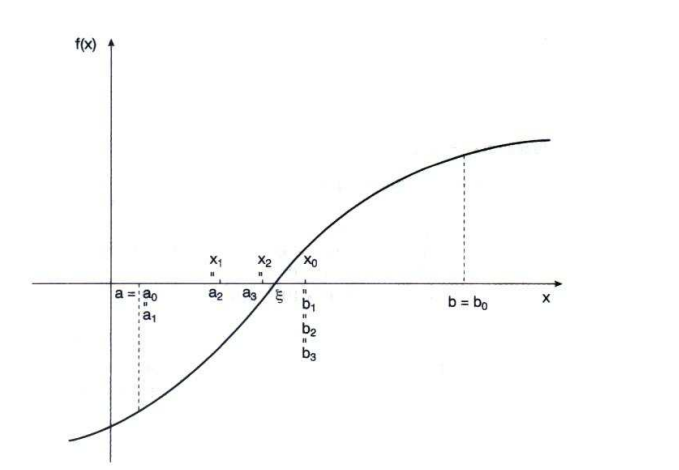

O Método da Bisseção é um algoritmo utilizado para encontrar raízes de funções (contínuas), do qual o seu funcionamento baseia-se na divisão de um intervalo ao meio repetidamente, assegurando que a raíz esteja dentro dentro desse intervalo ou dentro de um subintervalo até que a aproximação atinja o valor desejado. Ou seja, o objetivo do método da bisseção é diminuir o espaço do intervalo que possui a raiz até chegarmos no valo de $(b - a)  <1 ϵ$.
<br>
Neste caso, a fórmula para encontrar x é:
$$
x = \frac{a + b}{2}
$$

###*Método da Posição Falsa*

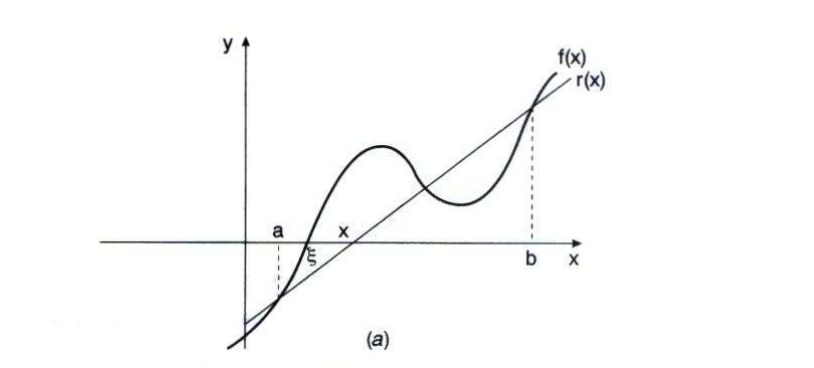

O Método da Posição Falsa é um algoritmo iterativo, sendo considerado uma variação do Método da Bisseção, que é utilizado para encontrar raízes de uma determinada função através de um dado intervalo $[a, b]$, tal que $f(a) * f(b) < 0$, ou seja, $f(a)$ e $f(b)$ possuem sinais opostos. Logo, o método irá calcula a aproximação da raíz como o ponto de interseção entre a reta secante e $f$ aos $(a, f(a))$ e $(b, f(b))$. Ou seja, quando a reta secante cruza o eixo x.
<br>
Deste modo, calculamos a raíz através da seguinte fórmula:

$$
x = \frac{a * f(b) - b * f(a)}{f(b) - f(a)}
$$

###*Método do Ponto Fixo*

a)

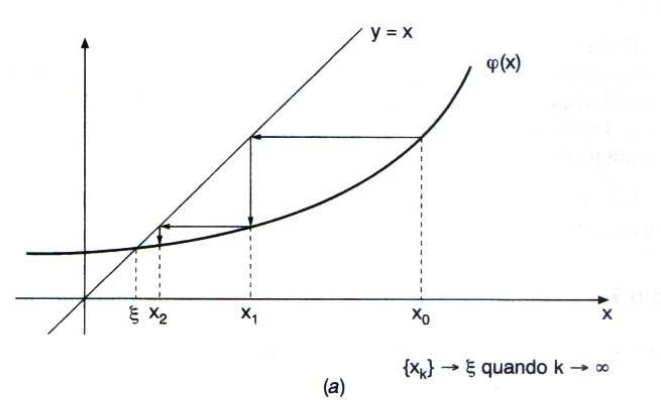

b)

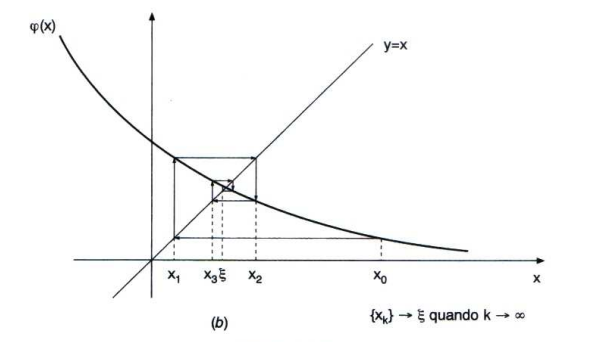

c)

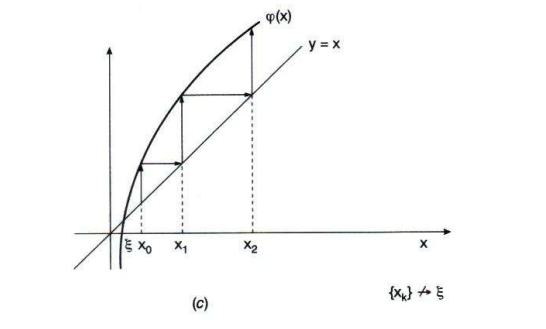

d)

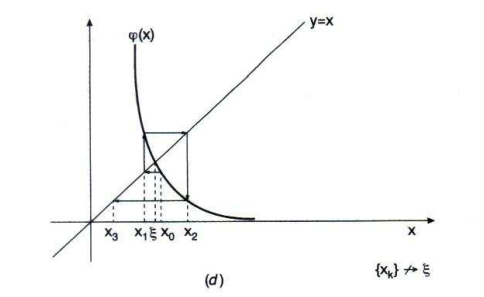

O Método do Ponto Fixo é utilizado para calcular-se pontos fixos de funções contínuas, no qual, dada uma função $f(x)$ a transformamos em uma função equivalente $x = ϕ(x)$ e com um valor inicial (aproximação) podemos gerar uma sequência $x_{k+1} = g(x_k)$, com o objetivo de convergir para a raiz, contando que $g(x)$ seja contínua e $|g'(x)| < 1$.
<br>
Deste modo, não há uma fórmula específica para fazer o cálculo da aproximção, já que isso depende da função que está sendo verificada para criarmos uma equivalente.

###*Método Newton-Raphson*

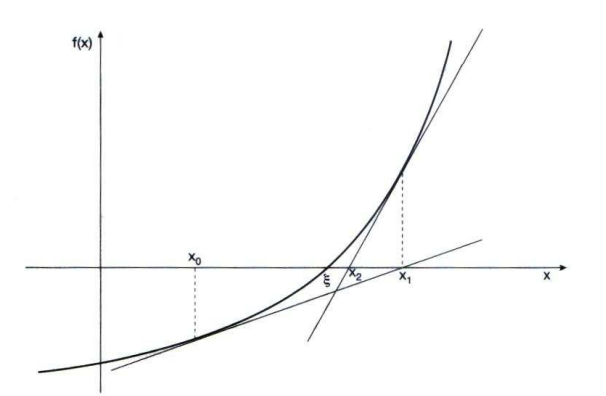

O Método Newton-Raphson é uma técnica iterativa que utilizamos para encontrar raízes, possui como objetivo ser usado para calcular raízes de funções não-lineares.
<br>
Sendo assim, inicialmente é necessário escolher uma aproximação e após isso deve-se encontrar a equação da reta tangente (derivando) a função nesse ponto e também a interseção dela com o eixo das abcissas, para que a aproximação seja a melhor possível, e com isso repete-se o algoritmo de maneira iterativa até que a raiz da função seja encontrada.
<br>
Deste modo, a fórmula utilizada é:
$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
$$

###*Método da Secante*

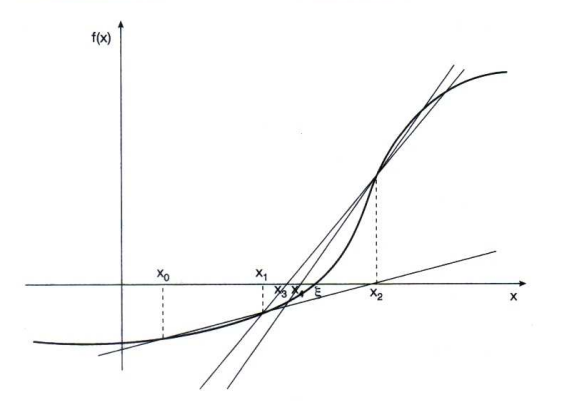

O Método da Secante é um algoritmo iterativo que é usado para encontrar raízes de funções não lineares, que utiliza o princípio de aproximar usando a secante para dispensar o cálculo da derivada, deste modo, é necessário usar dois pontos iniciais para conseguir gerar a aproximação seguinte até encontrar a raiz.
<br>
A fórmula geral utilizada é:
$$
x_{k+1} = x_k - \frac{f(x_k)* (x_k - x_{k-1})}{f(x_k) - f(x_{k-1})}
$$

###*Letra A*

###*Tabela Exemplo 18*

In [60]:
tabela, cabeca = desenhar_tabela(18)

print(tabulate(tabela, headers=cabeca, tablefmt="simple"))

                     Bisseção                Posição Falsa           MPF                     Newton                 Secante
-------------------  ----------------------  ----------------------  ----------------------  ---------------------  ----------------------
Dados Iniciais       [1, 2]                  [1, 2]                  x_0 = 1.5               x_0 = 1.5              x_0 = 1; x_1 = 2
x̅                    1.44744873046875        1.4473570678005705      1.4473563506462803      -1.447414370126864     1.4474134472158682
f(x̅)                 2.192118039384683e-05   -3.638758569443623e-05  -3.684375421600383e-05  6.286949771894257e-08  -5.242249915965447e-07
Erro em X            2.9485468749923527e-05  6.217719942958055e-05   6.289435371975571e-05   2.8948336151268643     5.79778413190013e-06
Número de Iterações  14                      6                       10                      10                     5


###*Tabela Exemplo 19*

In [61]:
tabela, cabeca = desenhar_tabela(19)

print(tabulate(tabela, headers=cabeca, tablefmt="simple"))

                     Bisseção                 Posição Falsa           MPF                     Newton                  Secante
-------------------  -----------------------  ----------------------  ----------------------  ----------------------  -----------------------
Dados Iniciais       [1, 2]                   [1, 2]                  x_0 = 1                 x_0 = 0                 x_0 = 0; x_1 = 0.5
x̅                    1.3247175216674805       1.3247177628396751      1.3247178461621456      1.3247179572453902      1.3247179470666708
f(x̅)                 -1.8575764260120309e-06  -8.290661304144464e-07  -4.737264742704639e-07  2.7471358521324873e-12  -4.3405755212333474e-08
Erro em X            4.783325195933941e-07    2.3716032493403816e-07  1.538378544552188e-07   4.275460985248003e-08   5.2933329275361984e-08
Número de Iterações  20                       17                      9                       21                      26


###*Tabela Exemplo 20*

In [62]:
tabela, cabeca = desenhar_tabela(20)

print(tabulate(tabela, headers=cabeca, tablefmt="simple"))

                     Bisseção                 Posição Falsa          MPF                     Newton                   Secante
-------------------  -----------------------  ---------------------  ----------------------  -----------------------  ---------------------
Dados Iniciais       [0, 1]                   [0, 1]                 x_0 = 0.5               x_0 = 0.5                x_0 = 0; x_1 = 0
x̅                    0.37055206298828125      0.37055882835462395    0.37055611376057707     0.37055808376128907      0.37055809827709907
f(x̅)                 -1.3755001612603124e-05  1.669806334314572e-06  -4.51936095435812e-06   -2.7834957228023427e-08  5.260490709702026e-09
Erro em X            6.03840171875536e-06     7.269646239427274e-07  1.9876294229392855e-06  1.7628710935468916e-08   3.112900937018992e-09
Número de Iterações  17                       8                      5                       3                        7


###*Tabela Exemplo 21*

In [63]:
tabela, cabeca = desenhar_tabela(21)

print(tabulate(tabela, headers=cabeca, tablefmt="simple"))

                     Bisseção             Posição Falsa          MPF                  Newton                  Secante
-------------------  -------------------  ---------------------  -------------------  ----------------------  ---------------------
Dados Iniciais       [2, 3]               [2, 3]                 x_0 = 2.5            x_0 = 2.5               x_0 = 2.3; x_1 = 2.7
x̅                    2.9999999403953552   1.7632228461623611     2.71828181961404     1.763222834351898       1.763222834353273
f(x̅)                 2.2958367409172893   1.850869013608758e-08  1.7182818107690347   1.9984014443252818e-15  2.156941292241754e-12
Erro em X            0.49381552739535506  0.742961566837639      0.21209740661403975  0.7429615786481021      0.7429615786467272
Número de Iterações  24                   9                      14                   4                       5
